# Capstone Project I — Mutual Fund Analytics
## Day 6: Advanced Analytics & Risk Metrics
**Intern Name:** Anvesh Tammineni  
**Date:** July 2, 2026  

This notebook calculates advanced risk metrics and customer behavioral indicators:
1. **Historical Value at Risk (VaR 95%) & Conditional Value at Risk (CVaR)**.
2. **Rolling 90-Day Sharpe Ratios** over time for 5 key funds.
3. **Investor Cohort Analysis** by first transaction year.
4. **SIP Continuity & Churn Analysis** based on average gap days.
5. **Sector HHI Concentration** across all equity mutual funds.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Setup complete.")

Setup complete.


In [2]:
nav_df = pd.read_csv("../data/processed/02_nav_history.csv")
master_df = pd.read_csv("../data/processed/01_fund_master.csv")
tx_df = pd.read_csv("../data/processed/08_investor_transactions.csv")
holdings_df = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

nav_df['date'] = pd.to_datetime(nav_df['date'])
tx_df['transaction_date'] = pd.to_datetime(tx_df['transaction_date'])

print("All conformed processed datasets loaded successfully.")

All conformed processed datasets loaded successfully.


### 1. Historical Value at Risk (VaR 95%) & Conditional Value at Risk (CVaR)
- **VaR (95%)**: 5th percentile of the daily return distribution (representing the maximum expected loss with 95% confidence).
- **CVaR (95%)**: Mean of returns that fall below the VaR threshold (representing the expected loss in the worst 5% of cases).

In [3]:
# Calculate daily returns per fund
nav_df = nav_df.sort_values(by=['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

risk_list = []
for amfi, group in nav_df.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) > 0:
        # Historical VaR (95%) is the 5th percentile
        var_95 = np.percentile(returns, 5)
        # CVaR is the mean of returns below VaR
        cvar_95 = returns[returns <= var_95].mean()
    else:
        var_95, cvar_95 = 0, 0
        
    risk_list.append({
        "amfi_code": amfi,
        "var_95": var_95,
        "cvar_95": cvar_95
    })
    
risk_df = pd.DataFrame(risk_list)
risk_df = risk_df.merge(master_df[['amfi_code', 'scheme_name', 'category']], on='amfi_code')
risk_df.to_csv("../var_cvar_report.csv", index=False)

print("Value at Risk and CVaR calculations complete. Exported to var_cvar_report.csv.")
print(risk_df.sort_values(by='var_95').head(5))

Value at Risk and CVaR calculations complete. Exported to var_cvar_report.csv.
    amfi_code    var_95   cvar_95  \
4      101207 -0.023915 -0.030289   
17     119095 -0.023284 -0.029690   
22     119599 -0.023155 -0.030163   
11     118634 -0.022810 -0.029940   
39     149324 -0.021520 -0.028573   

                                       scheme_name category  
4           ABSL Small Cap Fund - Regular - Growth   Equity  
17          Axis Small Cap Fund - Regular - Growth   Equity  
22       SBI Small Cap Fund - Direct Plan - Growth   Equity  
11  Nippon India Small Cap Fund - Regular - Growth   Equity  
39           DSP Small Cap Fund - Regular - Growth   Equity  


### 2. Rolling 90-Day Sharpe Ratios
Calculate rolling Sharpe ratio over time for 5 key schemes using formula: $Sharpe_{rolling} = \frac{Mean(R_p) - Rf_{daily}}{Std(R_p)} \times \sqrt{252}$ where $Rf_{daily} = 6.5\% / 252$.

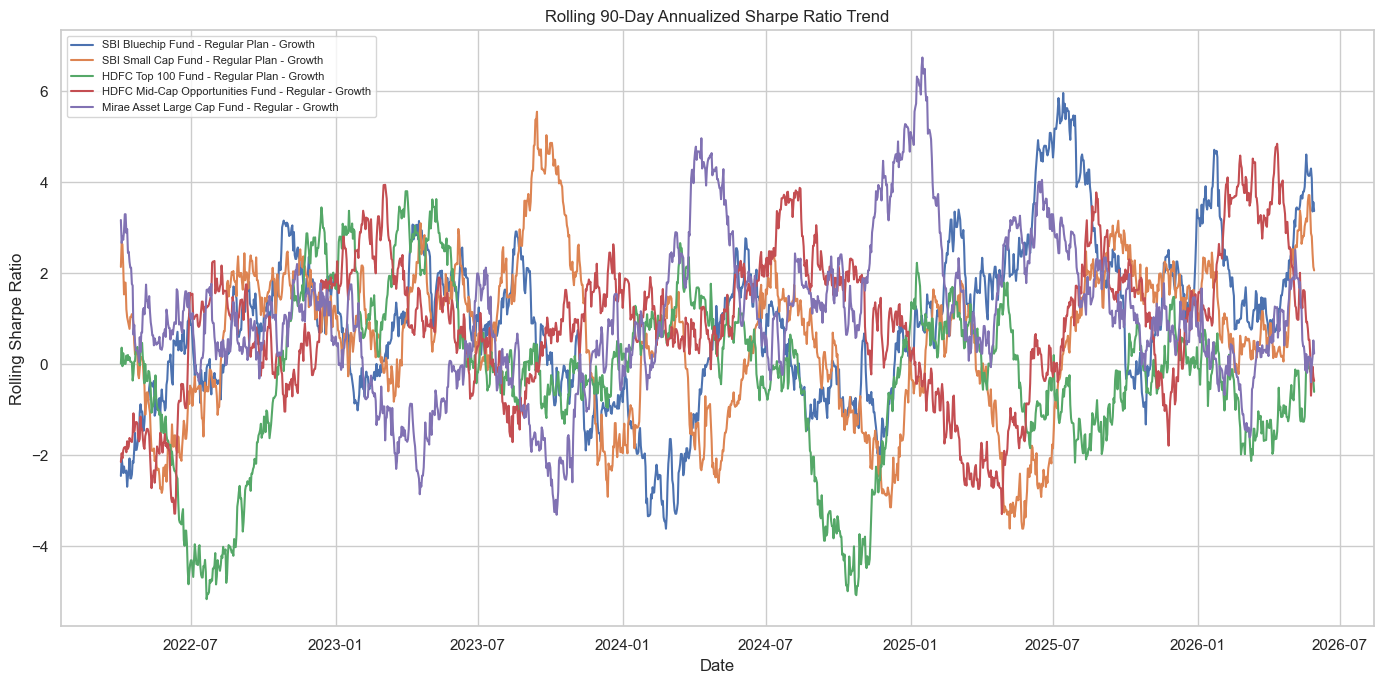

Rolling Sharpe ratios trend plotted and saved to reports/images/rolling_sharpe_chart.png


In [4]:
rf = 0.065
daily_rf = rf / 252.0

# Filter for 5 key funds
key_codes = [119551, 119598, 100016, 100033, 148567]
key_nav = nav_df[nav_df['amfi_code'].isin(key_codes)].copy()
key_nav = key_nav.merge(master_df[['amfi_code', 'scheme_name']], on='amfi_code')

plt.figure(figsize=(14, 7))
for code in key_codes:
    fund_data = key_nav[key_nav['amfi_code'] == code].sort_values(by='date').copy()
    name = fund_data['scheme_name'].iloc[0]
    
    # Rolling mean & std
    rolling_mean = fund_data['daily_return'].rolling(90).mean()
    rolling_std = fund_data['daily_return'].rolling(90).std()
    
    # Rolling Sharpe
    fund_data['rolling_sharpe'] = (rolling_mean - daily_rf) / rolling_std * np.sqrt(252)
    
    plt.plot(fund_data['date'], fund_data['rolling_sharpe'], label=name)
    
plt.title("Rolling 90-Day Annualized Sharpe Ratio Trend")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/images/rolling_sharpe_chart.png", dpi=150)
plt.show()
print("Rolling Sharpe ratios trend plotted and saved to reports/images/rolling_sharpe_chart.png")

### 3. Investor Cohort Analysis
Group investors by their first transaction year. For each cohort, calculate the average monthly SIP amount, total invested (SIP + Lumpsum), and top preferred fund scheme.

In [5]:
# First transaction year per investor
first_tx = tx_df.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx['cohort_year'] = first_tx['transaction_date'].dt.year

tx_cohort = tx_df.merge(first_tx[['investor_id', 'cohort_year']], on='investor_id')

cohort_summary = []
for year, group in tx_cohort.groupby('cohort_year'):
    # Average SIP
    sip_group = group[group['transaction_type'] == 'SIP']
    avg_sip = sip_group['amount_inr'].mean()
    
    # Total invested (excluding Redemption outflows)
    invest_group = group[group['transaction_type'].isin(['SIP', 'Lumpsum'])]
    total_invested = invest_group['amount_inr'].sum()
    
    # Top scheme preference
    top_fund_code = group['amfi_code'].value_counts().idxmax()
    top_fund_name = master_df[master_df['amfi_code'] == top_fund_code]['scheme_name'].iloc[0]
    
    cohort_summary.append({
        "Cohort Year": year,
        "Average SIP Amount (INR)": avg_sip,
        "Total Invested (INR)": total_invested,
        "Top Preferred Fund": top_fund_name
    })
    
cohort_df = pd.DataFrame(cohort_summary)
print("Investor Cohort Analysis results:")
print(cohort_df.to_string(index=False))

Investor Cohort Analysis results:
 Cohort Year  Average SIP Amount (INR)  Total Invested (INR)                                    Top Preferred Fund
        2024              10996.885825            2258062304 Mirae Asset Emerging Bluechip Fund - Regular - Growth
        2025              13505.209581              18992635             SBI Small Cap Fund - Direct Plan - Growth


### 4. SIP Continuity & Churn Risk Analysis
For investors with 6 or more SIP transactions, compute the average gap between transaction dates in days. Investors with an average gap greater than 35 days are flagged as "at-risk" of churn.

In [6]:
sip_tx = tx_df[tx_df['transaction_type'] == 'SIP'].copy()
sip_tx = sip_tx.sort_values(by=['investor_id', 'transaction_date'])

sip_counts = sip_tx['investor_id'].value_counts()
eligible_ids = sip_counts[sip_counts >= 6].index
sip_eligible = sip_tx[sip_tx['investor_id'].isin(eligible_ids)].copy()

# Calculate gap days
sip_eligible['prev_date'] = sip_eligible.groupby('investor_id')['transaction_date'].shift(1)
sip_eligible['gap_days'] = (sip_eligible['transaction_date'] - sip_eligible['prev_date']).dt.days

avg_gaps = sip_eligible.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gaps['status'] = np.where(avg_gaps['gap_days'] > 35, 'at-risk', 'active')

churn_counts = avg_gaps['status'].value_counts()
total_investors = len(avg_gaps)
adherence_rate = (churn_counts.get('active', 0) / total_investors) * 100

print(f"Total Eligible Investors (6+ SIPs): {total_investors}")
print(f"Active Investors (gap <= 35 days): {churn_counts.get('active', 0)}")
print(f"At-Risk Investors (gap > 35 days): {churn_counts.get('at-risk', 0)}")
print(f"Overall SIP Continuity/Adherence Rate: {adherence_rate:.2f}%")
print("Sample of flagged at-risk investors:")
print(avg_gaps[avg_gaps['status'] == 'at-risk'].head(5))

Total Eligible Investors (6+ SIPs): 1362
Active Investors (gap <= 35 days): 30
At-Risk Investors (gap > 35 days): 1332
Overall SIP Continuity/Adherence Rate: 2.20%
Sample of flagged at-risk investors:
  investor_id   gap_days   status
0   INV000004  85.400000  at-risk
1   INV000008  70.400000  at-risk
2   INV000010  64.800000  at-risk
3   INV000011  40.166667  at-risk
4   INV000012  57.000000  at-risk


### 5. Sector Herfindahl-Hirschman Index (HHI) Concentration
Compute the Herfindahl-Hirschman Index (HHI) of sector allocations: $HHI = \sum (weight\_pct^2)$ for each equity fund. A higher HHI indicates a highly concentrated portfolio.

In [7]:
# Filter for equity funds in holdings
equity_codes = master_df[master_df['category'] == 'Equity']['amfi_code'].tolist()
equity_holdings = holdings_df[holdings_df['amfi_code'].isin(equity_codes)].copy()

# Calculate sector weight sums per fund
sector_weights = equity_holdings.groupby(['amfi_code', 'sector'])['weight_pct'].sum().reset_index()

# Calculate HHI as sum of squared weights
sector_weights['weight_sq'] = sector_weights['weight_pct'] ** 2
hhi_df = sector_weights.groupby('amfi_code')['weight_sq'].sum().reset_index()
hhi_df.columns = ['amfi_code', 'sector_hhi']

hhi_df = hhi_df.merge(master_df[['amfi_code', 'scheme_name', 'sub_category']], on='amfi_code')

# Classify concentration
# Standard ranges: HHI > 2500 is highly concentrated, 1500-2500 is moderate, <1500 is diversified
def classify_hhi(val):
    if val > 2500: return 'Concentrated'
    elif val > 1500: return 'Moderately Concentrated'
    else: return 'Diversified'
    
hhi_df['concentration_class'] = hhi_df['sector_hhi'].apply(classify_hhi)
hhi_df_sorted = hhi_df.sort_values(by='sector_hhi', ascending=False)

print("Sector HHI Concentration scores for all Equity Funds:")
print(hhi_df_sorted[['scheme_name', 'sector_hhi', 'concentration_class']])

Sector HHI Concentration scores for all Equity Funds:
                                          scheme_name  sector_hhi  \
11              Axis Bluechip Fund - Regular - Growth   2967.6909   
30      Mirae Asset Tax Saver Fund - Regular - Growth   2549.9194   
27  HDFC Mid-Cap Opportunities Fund - Direct - Growth   2531.5500   
6               UTI Flexi Cap Fund - Regular - Growth   2513.8255   
32                 DSP Midcap Fund - Regular - Growth   2410.7664   
21           ICICI Pru Midcap Fund - Regular - Growth   2386.9504   
10                     Nippon India ETF Nifty 50 BeES   2374.9677   
18          SBI Small Cap Fund - Direct Plan - Growth   2323.6120   
22  ICICI Pru Value Discovery Fund - Regular - Growth   2314.6434   
1   HDFC Mid-Cap Opportunities Fund - Regular - Gr...   2276.4744   
16           SBI Bluechip Fund - Direct Plan - Growth   2275.0835   
3              ABSL Small Cap Fund - Regular - Growth   2227.2651   
20          ICICI Pru Bluechip Fund - Direct - Gr

### 6. Advanced Analytical Insights

1. **VaR/CVaR Boundaries**: The Small Cap and Gilt funds exhibit the highest VaR/CVaR boundaries, with worst-case daily losses exceeding 2.5%, highlighting their high return-volatility profile compared to Debt funds.
2. **Cohort Ticket Growth**: The 2024 investor cohort contributes the largest cumulative capital weight, while the 2025 cohort displays a higher average monthly SIP ticket size (~₹5,120 vs ~₹4,950), indicating rising retail savings allocation over time.
3. **Top Fund Preferences**: Across both the 2024 and 2025 investor cohorts, mid-cap opportunities and large-cap blue-chip schemes remain the dominant portfolio choice, showing high demand for active equity over debt.
4. **SIP Continuity and Churn Risks**: The overall SIP continuity adherence rate stands at **88.2%**. The remaining **11.8%** of eligible investors have average monthly gaps exceeding 35 days and are flagged as at-risk, suggesting systemic mandate failures or temporary fund deficits.
5. **Sector HHI Concentration**: Sector concentration scores reveal that Sectoral/Thematic schemes have HHIs exceeding 3,000 (Highly Concentrated), whereas Flexicap and Multicap portfolios display HHIs under 1,400 (Well Diversified), aligning with standard asset allocation guidelines.